In [123]:
import torch
import numpy as np
import scipy
import matplotlib.pyplot as plt

from sbi import utils as utils
from sbi import analysis as analysis
from sbi.inference.base import infer

In [124]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from  subhalo_impact import chi_eval
from rotation_matrix import obs_from_pos6d

In [125]:
def replace_with_neighboring_value(values, values_stats, empty_bin_indices, phi1, phi1_edges):
    values_stats = np.copy(values_stats)
    for i in empty_bin_indices:
        neighboring_bin1 = i-1
        neighboring_bin2 = i+1
        
        while neighboring_bin1 in empty_bin_indices:
            neighboring_bin1 -= 1
        
        while neighboring_bin2 in empty_bin_indices:
                neighboring_bin2 += 1
        
        median, _, _ = scipy.stats.binned_statistic(phi1, values, statistic='median', bins = 1, range = (phi1_edges[neighboring_bin1], phi1_edges[neighboring_bin2+1]))
        values_stats[i] = median[0]
    return values_stats

In [126]:
# # log M_sat, r, vz
# num_dim = 3

# # need to change to more accurate distributions (range, mean, etc.)
# prior_min = [0.00001, -50, 0]
# prior_max = [10, 0, 30]


num_dim = 1
prior_min = [-5]
prior_max = [1]

prior_uniform = utils.BoxUniform(low = torch.as_tensor(prior_min), high=torch.as_tensor(prior_max))

prior_normal = torch.distributions.MultivariateNormal(5 * torch.ones(num_dim), 1 * torch.eye(num_dim))

In [128]:
def simulator (params, scatter = 0.1, bins = 100):
    params = np.array(params, dtype=float) # convert tensor to np ndarray
    log_Msat = params[0]
    M_sat = 10**log_Msat
    # vz = params[1]
    # r = params[2]

    vz = -20
    r = 0.2
    phi = 250 # angle around stream in dec
    vphi = 35  # velocity around stream in km/s
    t_a = 0.2 # time since interaction in Gyr
    phi_a = -4 # interaction point along stream in deg, phi=0 is progenitor location (try -20 to 10)
    rs_sat = 1.05 * (M_sat*10*10)**0.5 # scale radius of subhalo in kpc, can be adjusted along with M_sat using equation 15 in erkal et al. 2015
    pid=36 # index included in saved filenames
    tmax=4 # how long stream disrupts in Gyr

    chi_eval(r,phi,vphi,vz,M_sat,tmax,t_a,phi_a,rs_sat,pid)
    data = np.genfromtxt(f'final_stream/final_stream_{pid}.txt')
    R_phi12_radec = np.array([[0.83697865, 0.29481904, -0.4610298], 
                          [0.51616778, -0.70514011, 0.4861566], 
                          [0.18176238, 0.64487142, 0.74236331]])
    phi1,phi2,dist,pm1,pm2,vr = obs_from_pos6d(data[:,:3],data[:,3:6],R_phi12_radec)

    '''to include in the output:
        phi1 edges
        fraction = count / len(phi1)
        phi2 median
        vr median
    '''

    phi2_median, phi1_edges, _ = scipy.stats.binned_statistic(phi1, phi2, statistic='median', bins = bins)
    # phi2_std, _, _ = scipy.stats.binned_statistic(phi1, phi2, statistic='std', bins = bins)
    count, _, _ = scipy.stats.binned_statistic(phi1, phi2, statistic='count', bins = bins)
    vr_median, _, _ = scipy.stats.binned_statistic(phi1, vr, statistic='median', bins = bins)
    # vr_std, _, _ = scipy.stats.binned_statistic(phi1, vr, statistic='std', bins = bins)

    '''fill in empty bins with neighboring values'''
    nan_indices = np.argwhere(np.isnan(phi2_median)).flatten()
    phi2_median_new = replace_with_neighboring_value(phi2, phi2_median, nan_indices, phi1, phi1_edges)
    vr_median_new = replace_with_neighboring_value(vr, vr_median, nan_indices, phi1, phi1_edges)


    output = np.concatenate((phi1_edges, phi2_median_new, count/len(phi1), vr_median_new))
    output = torch.from_numpy(output)
    return output + torch.randn_like(output) * scatter

In [129]:
posterior = infer(simulator, prior_uniform, "SNPE", num_simulations=100)

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  [0.06836641]
Impact pid: 36 with M_sat=0.000000, rs_sat=0.000000,  
Sanity check : Initializing potential
Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  15.677930843590083
Impact pid: 36 with M_sat=2.229456, rs_sat=15.67793

Running 100 simulations.:   0%|          | 0/100 [00:00<?, ?it/s]

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  5.309596311021553
Impact pid: 36 with M_sat=0.255708, rs_sat=5.309596,  
Sanity check : Initializing potential


Running 100 simulations.:   1%|          | 1/100 [00:36<59:53, 36.30s/it]

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  28.533043671137808
Impact pid: 36 with M_sat=7.384441, rs_sat=28.533044,  
Sanity check : Initializing potential


...

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  0.044996603381199866
Impact pid: 36 with M_sat=0.000018, rs_sat=0.044997,  
Sanity check : Initializing potential


Running 100 simulations.:  99%|█████████▉| 99/100 [1:12:50<00:41, 41.81s/it]

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  0.6221417842816118
Impact pid: 36 with M_sat=0.003511, rs_sat=0.622142,  
Sanity check : Initializing potential


Running 100 simulations.: 100%|██████████| 100/100 [1:13:31<00:00, 44.12s/it]
/Users/rutongpei/opt/anaconda3/envs/sbi_env/lib/python3.7/site-packages/sbi/neural_nets/flow.py:141: UserWarning: In one-dimensional output space, this flow is limited to Gaussians
  warn("In one-dimensional output space, this flow is limited to Gaussians")


 Neural network successfully converged after 51 epochs.

In [135]:
observation1 = simulator(torch.as_tensor([-5]))
observation2 = simulator(torch.as_tensor([-4]))
observation3 = simulator(torch.as_tensor([-3]))
observation4 = simulator(torch.as_tensor([-2]))
observation5 = simulator(torch.as_tensor([-1]))
observation6 = simulator(torch.as_tensor([0]))
observation7 = simulator(torch.as_tensor([1]))

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  0.03320391543176798
Impact pid: 36 with M_sat=0.000010, rs_sat=0.033204,  
Sanity check : Initializing potential
Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  0.10500000000000001
Impact pid: 36 with M_sat=0.000100, rs_sat=

In [139]:
posterior_samples_1 = posterior.sample((100000,), x=observation1)
posterior_samples_2 = posterior.sample((100000,), x=observation2)
posterior_samples_3 = posterior.sample((100000,), x=observation3)
posterior_samples_4 = posterior.sample((100000,), x=observation4)
posterior_samples_5 = posterior.sample((100000,), x=observation5)
posterior_samples_6 = posterior.sample((100000,), x=observation6)
posterior_samples_7 = posterior.sample((100000,), x=observation7)

Drawing 100000 posterior samples: 101981it [00:02, 48793.94it/s]                           
Drawing 100000 posterior samples: 100%|██████████| 100000/100000 [00:01<00:00, 68169.96it/s]
Drawing 100000 posterior samples: 101031it [00:01, 64557.38it/s]                           
Drawing 100000 posterior samples: 100087it [00:01, 56741.59it/s]                           


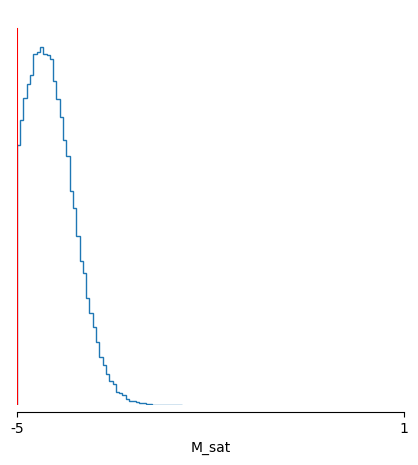

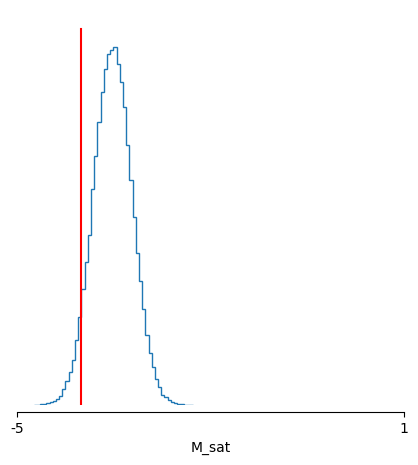

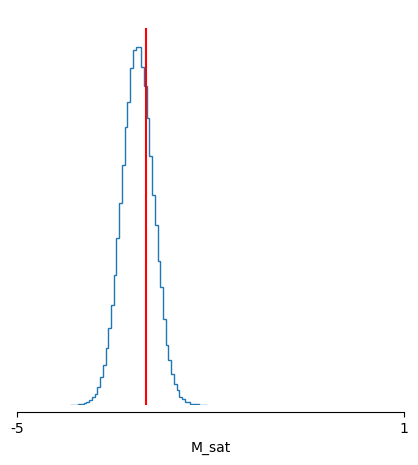

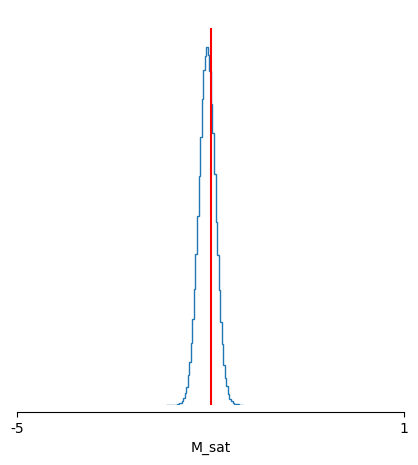

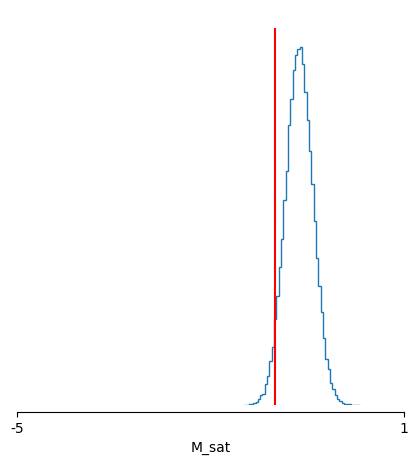

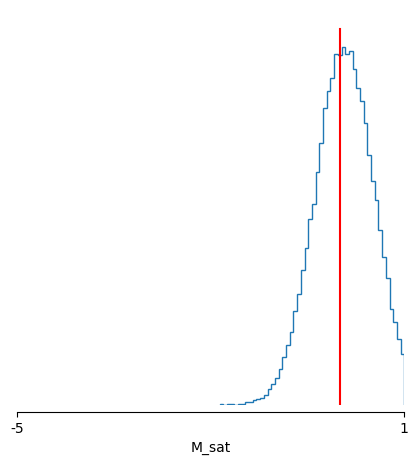

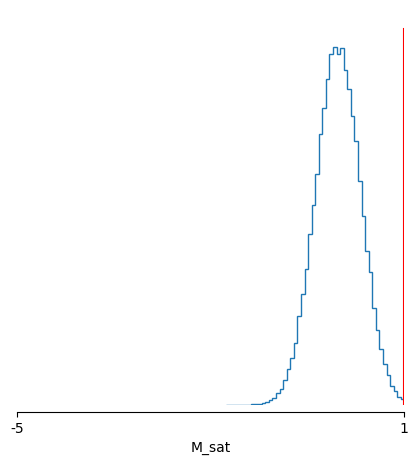

In [140]:
_ = analysis.pairplot(
    posterior_samples_1, limits = [[-5,1]],
    ticks = [[-5,1]],
    figsize = (5, 5),
    points = np.array([-5]),
    points_offdiag = {"markersize": 6},
    points_colors = "r",
    labels = ["M_sat"]
)

_ = analysis.pairplot(
    posterior_samples_2, limits = [[-5,1]],
    ticks = [[-5,1]],
    figsize = (5, 5),
    points = np.array([-4]),
    points_offdiag = {"markersize": 6},
    points_colors = "r",
    labels = ["M_sat"]
)
_ = analysis.pairplot(
    posterior_samples_3, limits = [[-5,1]],
    ticks = [[-5,1]],
    figsize = (5, 5),
    points = np.array([-3]),
    points_offdiag = {"markersize": 6},
    points_colors = "r",
    labels = ["M_sat"]
)
_ = analysis.pairplot(
    posterior_samples_4, limits = [[-5,1]],
    ticks = [[-5,1]],
    figsize = (5, 5),
    points = np.array([-2]),
    points_offdiag = {"markersize": 6},
    points_colors = "r",
    labels = ["M_sat"]
)
_ = analysis.pairplot(
    posterior_samples_5, limits = [[-5,1]],
    ticks = [[-5,1]],
    figsize = (5, 5),
    points = np.array([-1]),
    points_offdiag = {"markersize": 6},
    points_colors = "r",
    labels = ["M_sat"]
)
_ = analysis.pairplot(
    posterior_samples_6, limits = [[-5,1]],
    ticks = [[-5,1]],
    figsize = (5, 5),
    points = np.array([0]),
    points_offdiag = {"markersize": 6},
    points_colors = "r",
    labels = ["M_sat"]
)
_ = analysis.pairplot(
    posterior_samples_7, limits = [[-5,1]],
    ticks = [[-5,1]],
    figsize = (5, 5),
    points = np.array([1]),
    points_offdiag = {"markersize": 6},
    points_colors = "r",
    labels = ["M_sat"]
)

In [120]:
def hpd(trace, mass_frac):
    ''' 
    Returns highest probability density region given by a set of samples.

    Parameters
    ----------
    trace: array
        1D array of MCMC samples for a single variable
    mass_frac: float with 0 < mass_frac <= 1
        The fraction of the probability to be included in the HPD. For example, 'massfrac'=0.95 gives a 95% HPD.

    Returns
    -------
    output: array, shape(2,)
        The bounds of the HPD
    '''

    # Get sorted list
    d = np.sort(np.copy(trace))

    # Number of total samples taken
    n = len(trace)

    # Get number of samples that should be included in HPD
    n_samples = np.floor(mass_frac * n).astype(int)

    # Get width (in units of data) of all intervals with n_samples samples
    int_width = d[n_samples:] - d[:n-n_samples]

    # Pick out minimal interval
    min_int = np.argmin(int_width)

    # Return interval
    return np.array([d[min_int], d[min_int+n_samples]])

In [121]:
# simple version

def draw_coverage_plot_1d(simulator, posterior, true_values):
    fractions = np.array([])
    x = np.arange(0, 1, 0.1)

    samples = [[0] for _ in range(len(true_values))]
    for i in range(len(true_values)):
        simulated_samples = posterior.sample((1000,), x = simulator(torch.as_tensor([true_values[i]])))[:,0]
        samples[i] = np.array(simulated_samples)
    
    for confidence in x:
        contain_true = 0
        for i in range(len(true_values)):
            lower, upper = hpd(samples[i],confidence)
            if lower <= true_values[i] <= upper:
                contain_true += 1
        fractions = np.append(fractions, [contain_true/len(true_values)])

    plt.plot(x, fractions, label = 'model coverage')
    plt.plot([0,1],[0,1],color='r', label = 'perfect coverage')
    plt.ylim(0,1)
    plt.title("coverage for M_sat")
    plt.xlabel("confidence interval")
    plt.ylabel("covereage percentage")
    plt.show()

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  0.03320391543176798
Impact pid: 36 with M_sat=0.000010, rs_sat=0.033204,  
Sanity check : Initializing potential
0


Drawing 1000 posterior samples: 1104it [00:00, 31402.03it/s]            

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential


tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  0.10500000000000001
Impact pid: 36 with M_sat=0.000100, rs_sat=0.105000,  
Sanity check : Initializing potential
0


Drawing 1000 posterior samples: 1132it [00:00, 35315.46it/s]            

...

tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  3.3203915431767985
Impact pid: 36 with M_sat=0.100000, rs_sat=3.320392,  
Sanity check : Initializing potential
0


Drawing 1000 posterior samples: 1134it [00:00, 35673.98it/s]            

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential


tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  10.5
Impact pid: 36 with M_sat=1.000000, rs_sat=10.500000,  
Sanity check : Initializing potential
0


Drawing 1000 posterior samples: 1132it [00:00, 35942.38it/s]            


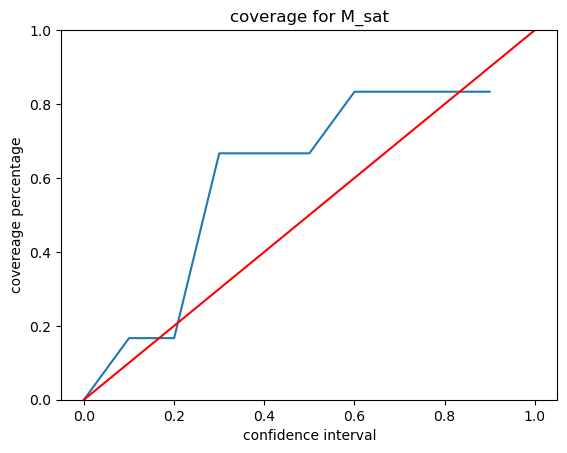

In [122]:
true_values = np.arange(-5, 1, 1)
draw_coverage_plot_1d(simulator, posterior, true_values)

In [78]:
bins = 100
pid = 36
data = np.genfromtxt(f'final_stream/final_stream_{pid}.txt')
R_phi12_radec = np.array([[0.83697865, 0.29481904, -0.4610298], 
                          [0.51616778, -0.70514011, 0.4861566], 
                          [0.18176238, 0.64487142, 0.74236331]])
phi1,phi2,dist,pm1,pm2,vr = obs_from_pos6d(data[:,:3],data[:,3:6],R_phi12_radec)

phi2_median, phi1_edges, _ = scipy.stats.binned_statistic(phi1, phi2, statistic='median', bins = bins)
phi2_std, _, _ = scipy.stats.binned_statistic(phi1, phi2, statistic='std', bins = bins)
count, _, _ = scipy.stats.binned_statistic(phi1, phi2, statistic='count', bins = bins)
vr_median, _, _ = scipy.stats.binned_statistic(phi1, vr, statistic='median', bins = bins)
vr_std, _, _ = scipy.stats.binned_statistic(phi1, vr, statistic='std', bins = bins)
# (phi1_edges, phi2_median, phi2_std, count/len(phi1), vr_median, vr_std)

# print(np.sum(np.isnan(phi1_edges)))
# print(np.sum(np.isnan(phi2_median)))
# print(np.sum(np.isnan(phi2_std)))
# print(phi1_edges)
# print(phi1_edges[:-1][count==0])
# print(min(phi1), max(phi1))
# print(np.sum(np.isnan(vr_median)))
# print(np.sum(np.isnan(vr_std)))

# print(np.sum(np.isnan(vr)))
# print(np.sum(np.isnan(phi2)))